In [4]:
import os
import prescient.utils
import numpy as np
import pandas as pd
import sklearn
import umap
import scipy
import annoy
import torch
import matplotlib.pyplot as plt

[KeOps] Warning : Cuda libraries were not detected on the system or could not be loaded ; using cpu only mode


In [5]:
import scanpy as sc

In [6]:
os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

## Load data

Make sure to have downloaded the Veres 2019 et. al. data to this directory as described on the "Usage notebooks" tab.

In [12]:
adata = sc.read_h5ad(f"data/klein_subset.h5ad")
cellstate_key = "DM_EigenVectors_multiscaled"
n_dimension = 5
base_cellstate = adata.obsm[cellstate_key][:,:n_dimension].copy()

In [33]:
def msigdb_tsv_2_genelist(tsv, save_to=None):

    # read 
    Msigdb_gs = pd.read_table(tsv, index_col=0)
    Msigdb_list = Msigdb_gs.loc['GENE_SYMBOLS'].item().split(',')

    if save_to is not None:
        Msigdb = pd.DataFrame({"gene_symbol":Msigdb_list})
        Msigdb.to_csv(save_to)
        print('gene set saved to ', save_to)
    
    return Msigdb_list

In [ ]:
# read the tsv download 
# from Msigdb: https://www.gsea-msigdb.org/gsea/msigdb/mouse/geneset/HALLMARK_APOPTOSIS.html
g2m_gs_list = msigdb_tsv_2_genelist("data/mouse_geneset/HALLMARK_G2M_CHECKPOINT.v2024.1.Mm.tsv",
                        save_to = "data/mouse_geneset/mouse_hallmark_g2m.csv")

apop_gs_list = msigdb_tsv_2_genelist("data/mouse_geneset/HALLMARK_APOPTOSIS.v2024.1.Mm.tsv",
                        save_to = "data/mouse_geneset/mouse_hallmark_apoptosis.csv")

cellcycle_list = msigdb_tsv_2_genelist("data/mouse_geneset/GOBP_MITOTIC_CELL_CYCLE.v2024.1.Mm.tsv",
                        save_to = 'data/mouse_geneset/mouse_GOBP_cellcycle.csv')

GO_G2M_list = msigdb_tsv_2_genelist("data/mouse_geneset/GOBP_MITOTIC_G2_M_TRANSITION_CHECKPOINT.v2024.1.Mm.tsv",
                        save_to = 'data/mouse_geneset/mouse_GOBP_G2M.csv')

GO_G1S_list = msigdb_tsv_2_genelist("data/mouse_geneset/GOBP_MITOTIC_G1_S_TRANSITION_CHECKPOINT_SIGNALING.v2024.1.Mm.tsv",
                        save_to = 'data/mouse_geneset/mouse_GOBP_G1S.csv')

gene set saved to  data/mouse_geneset/mouse_GOBP_G1S.csv


In [37]:
len(np.intersect1d(cellcycle_list, adata.var_names))

141

In [54]:
len(np.intersect1d(hallmark_g2m_list, GO_G2M_list)), len(GO_G2M_list)

(7, 59)

In [51]:
len(np.intersect1d(GO_G2M_list, adata.var_names))

6

In [59]:
len(np.intersect1d(GO_G1S_list, adata.var_names))

3

In [38]:
len(np.intersect1d(hallmark_g2m_list, adata.var_names))

18

In [39]:
len(np.intersect1d(hallmark_apop_list, adata.var_names))

68

## Scale normalized expression for PCA
For PCA dimensionality reduction, scaled features are necessary. Here we use sklearn's StandardScaler().

In [25]:
expr = adata.X.copy()
scaler = sklearn.preprocessing.StandardScaler()
xs = pd.DataFrame(scaler.fit_transform(expr), index = adata.obs_names, columns = adata.var_names)

In [26]:
xp_ = adata.obsm['X_pca'].copy()

In [65]:
expr = pd.DataFrame(expr, index=adata.obs_names, columns=adata.var_names)

In [67]:
expr.to_csv("data/klein_subset_X.csv")

In [66]:
expr

,0610009E02Rik,0610009L18Rik,0610043K17Rik,1110002J07Rik,1110032F04Rik,1110034G24Rik,1190005I06Rik,1500002F19Rik,1500017E21Rik,1500026H17Rik,...,Znrf4,Zp3r,Zpld1,Zscan2,Zscan5b,mt-Atp6,mt-Atp8,mt-Co2,mt-Nd1,mt-Nd4
0,-0.070192,-0.05314,-0.009838,-0.016366,-0.020952,-0.064569,-0.054094,-0.022698,-0.033649,-0.046394,...,-0.009747,-0.007348,-0.007929,-0.023501,-0.010427,-0.321737,-0.24302,-0.970987,0.170852,-0.370280
1,-0.070192,-0.05314,-0.009838,-0.016366,-0.020952,-0.064569,-0.054094,-0.022698,-0.033649,-0.046394,...,-0.009747,-0.007348,-0.007929,-0.023501,-0.010427,-0.338877,-0.24302,-0.253019,0.333836,-0.104581
2,-0.070192,-0.05314,-0.009838,-0.016366,-0.020952,-0.064569,-0.054094,-0.022698,-0.033649,-0.046394,...,-0.009747,-0.007348,-0.007929,-0.023501,-0.010427,-0.299440,-0.24302,0.287141,0.343804,-0.499023
4,-0.070192,-0.05314,-0.009838,-0.016366,-0.020952,-0.064569,-0.054094,-0.022698,-0.033649,-0.046394,...,-0.009747,-0.007348,-0.007929,-0.023501,-0.010427,-0.180108,-0.24302,-0.118206,0.133922,-0.620592
6,-0.070192,-0.05314,-0.009838,-0.016366,-0.020952,-0.064569,-0.054094,-0.022698,-0.033649,-0.046394,...,-0.009747,-0.007348,-0.007929,-0.023501,-0.010427,-0.390565,-0.24302,0.015224,-0.773075,-1.011823
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130875,-0.070192,-0.05314,-0.009838,-0.016366,-0.020952,-0.064569,-0.054094,-0.022698,-0.033649,-0.046394,...,-0.009747,-0.007348,-0.007929,-0.023501,-0.010427,-0.484445,-0.24302,-0.720568,0.100738,-0.891341
130876,-0.070192,-0.05314,-0.009838,-0.016366,-0.020952,-0.064569,-0.054094,-0.022698,-0.033649,-0.046394,...,-0.009747,-0.007348,-0.007929,-0.023501,-0.010427,0.101833,-0.24302,0.128875,0.361108,0.182376
130877,-0.070192,-0.05314,-0.009838,-0.016366,-0.020952,-0.064569,-0.054094,-0.022698,-0.033649,-0.046394,...,-0.009747,-0.007348,-0.007929,-0.023501,-0.010427,0.082404,-0.24302,0.388670,-0.721796,0.258079
130879,-0.070192,-0.05314,-0.009838,-0.016366,-0.020952,-0.064569,-0.054094,-0.022698,-0.033649,-0.046394,...,-0.009747,-0.007348,-0.007929,-0.023501,-0.010427,-0.546687,-0.24302,-0.039756,0.019632,-0.027050


In [ ]:
metadata = adata.obs.copy()
metadata.to_csv("data/klein_subset_meta.csv", index=True)
metadata.head()

,Time_point,Population,Annotation,Well,time_cat,leiden,comb,label_man,clones,Meta clones,group,timepoint_tx_days,selected_clonal_cells,Day2_u,Day4_u,Day6_u,palantir_pseudotime,palantir_entropy
0,6.0,LK,undiff,2,6.0,16,undiff_16,prog_2,Clone_573,8,8,6.0,True,6.313256e-05,0.000072,0.000068,0.059343,1.158957e+00
1,6.0,LK,undiff,2,6.0,10,undiff_10,prog_Baso_Meg_Ery_Mast,Clone_1440,8,8,6.0,True,4.673292e-07,0.000003,0.000006,0.355230,3.426110e-01
2,6.0,LK,Monocyte,2,6.0,3,Monocyte_3,prog_Mono,Clone_394,0,0,6.0,True,2.084716e-06,0.000009,0.000015,0.105826,6.385202e-01
4,6.0,LK,undiff,2,6.0,9,undiff_9,prog_Meg_Ery,Clone_1972,4,4,6.0,True,2.516037e-06,0.000007,0.000011,0.188384,7.857315e-01
6,6.0,LK,Neutrophil,2,6.0,7,Neutrophil_7,prog_Neu,Clone_1450,3,3,6.0,True,1.135646e-07,0.000005,0.000007,0.412705,6.750768e-97


## Computing growth using built-in PRESCIENT commands

In [61]:
g_hallmark_growth, g_l=prescient.utils.get_growth_weights(xs, xp_, metadata, tp_col="Time_point",
                genes=adata.var_names, 
                birth_gst="data/mouse_geneset/mouse_hallmark_g2m.csv",
                death_gst="data/mouse_geneset/mouse_hallmark_apoptosis.csv",
                outfile="Explore_Notebook/8.Benchmark_v/Msig_hallmark_growth.pt"
                  )

In [ ]:
g_GOBP_cellcycle, g_l=prescient.utils.get_growth_weights(xs, xp_, metadata, tp_col="Time_point",
                genes=adata.var_names, 
                birth_gst="data/mouse_geneset/mouse_GOBP_cellcycle.csv",
                death_gst="data/mouse_geneset/mouse_hallmark_apoptosis.csv",
                outfile="Explore_Notebook/8.Benchmark_v/Msig_GOBP_cellcycle_growth.pt"
                  )

In [60]:
g_GOBP_g2m, g_l=prescient.utils.get_growth_weights(xs, xp_, metadata, tp_col="Time_point",
                genes=adata.var_names, 
                birth_gst="data/mouse_geneset/mouse_GOBP_G2M.csv",
                death_gst="data/mouse_geneset/mouse_hallmark_apoptosis.csv",
                outfile="Explore_Notebook/8.Benchmark_v/Msig_GOBP_G2M_growth.pt"
                  )

## Visualize growth weights
You can now visualize the computed growth/proliferation score per cell on a UMAP visualization of the data.

In [43]:
xu = adata.obsm['X_umap']

Text(0.5, 1.0, 'PRECIENT growth weight:\n hallmark G2M geneset \n hallmark apopotosis geneset ')

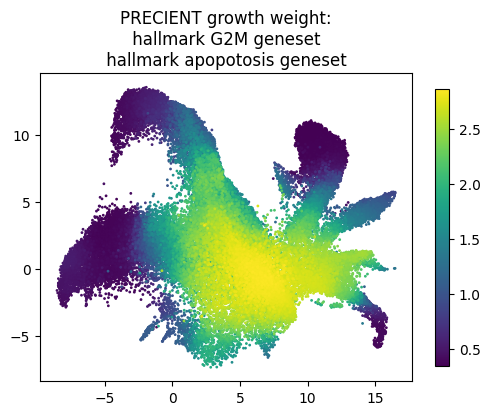

In [63]:
fig, ax = plt.subplots(figsize = (6,4))

c = np.exp(g_hallmark_growth)
ci = np.argsort(c)
sax = ax.scatter(xu[ci,0], xu[ci,1], s = 1, c = c[ci])

plt.colorbar(sax, shrink = 0.9)
ax.set_title("PRECIENT growth weight:\n hallmark G2M geneset \n hallmark apopotosis geneset ")

Text(0.5, 1.0, 'PRECIENT growth weight:\n GOBP cellcycle geneset \n hallmark apopotosis genest ')

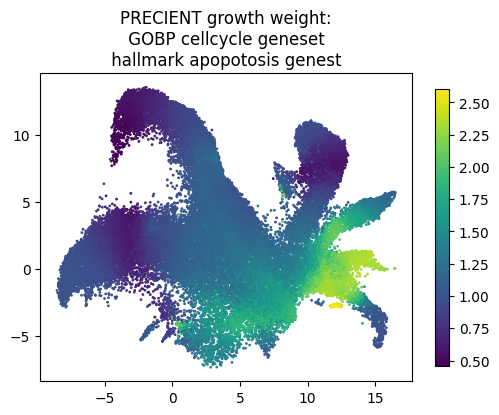

In [ ]:
fig, ax = plt.subplots(figsize = (6,4))

c = np.exp(g_GOBP_cellcycle)
ci = np.argsort(c)
sax = ax.scatter(xu[ci,0], xu[ci,1], s = 1, c = c[ci])

plt.colorbar(sax, shrink = 0.9)
ax.set_title("PRECIENT growth weight:\n GOBP cellcycle geneset \n hallmark apopotosis geneset ")

Text(0.5, 1.0, 'PRECIENT growth weight:\n GOBP g2m geneset \n hallmark apopotosis geneset ')

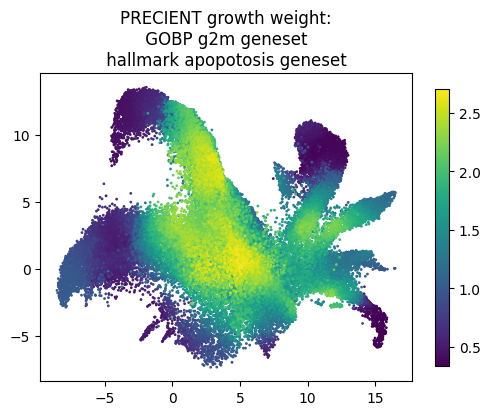

In [62]:
fig, ax = plt.subplots(figsize = (6,4))

c = np.exp(g_GOBP_g2m)
ci = np.argsort(c)
sax = ax.scatter(xu[ci,0], xu[ci,1], s = 1, c = c[ci])

plt.colorbar(sax, shrink = 0.9)
ax.set_title("PRECIENT growth weight:\n GOBP g2m geneset \n hallmark apopotosis geneset ")

## Use weight torch file in process_data command

In [ ]:
prescient process_data -d data/klein_subset_X.csv \
            -m data/klein_subset_meta.csv \
            --growth_path Explore_Notebook/8.Benchmark_v/Msig_GOBP_cellcycle_growth.pt \
            -o 'logs/PRESCIENT' --tp_col 'Time_point' --celltype_col 'label_man'

In [115]:
data['y']

[2, 4, 6]

In [2]:
import torch
import numpy as np

In [ ]:
prescient process_data -d data/klein_subset_X.csv \
            -m data/klein_subset_meta.csv \
            --growth_path Explore_Notebook/8.Benchmark_v/Msig_GOBP_cellcycle_growth.pt \
            -o 'data' --tp_col 'Time_point' --celltype_col 'label_man'

In [ ]:
data = torch.load("data/PRESCIENT_Weinreb_GOBP_cellcycle_data.pt")

tps = data['tps']
tps = np.where(tps==2, 0, tps)
tps = np.where(tps==4, 1, tps)
tps = np.where(tps==6, 2, tps)
data['tps'] = tps

data['y'] = np.array([0,1,2])
torch.save(data, "data/PRESCIENT_Weinreb_GOBP_cellcycle_data.pt")


In [14]:
DM = []
for t in sorted(metadata['Time_point'].unique()):
    DM_x = adata[metadata['Time_point'] == t].obsm[cellstate_key]
    DM.append(torch.tensor(DM_x))

data['xp'] = DM

In [15]:
torch.save(data, "data/PRESCIENT_Weinreb_GOBP_cellcycle_DMrepaced.pt")

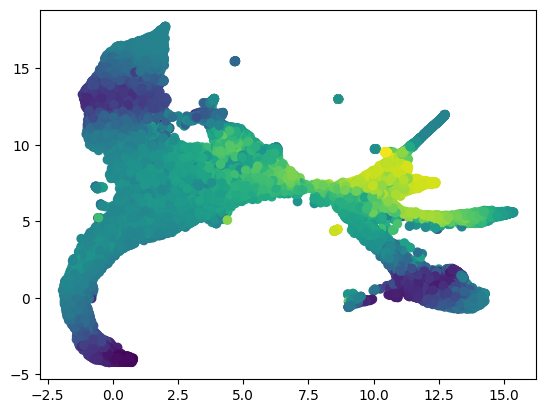

In [26]:
for i in range(3):
    xu = data['xu'][i].numpy()
    ww = data['w'][i]
    plt.scatter(xu[:,0], xu[:,1], c=ww)

You can now use the growth weights file produced in the process_data command as follows:
```
prescient process_data -d data/Veres2019/Stage_5.Seurat.csv -m data/Veres2019/GSE114412_Stage_5.all.cell_metadata.csv --growth_path data/Veres2019/growth-kegg.pt -o './' --tp_col 'CellWeek' --celltype_col 'Assigned_cluster'
```
This command will produce a ```data.pt``` file that is used for the remainder of the training, simulation, and perturbation steps of PRESCIENT as outlined in Quickstart and Documentation.

In [16]:
test_config = torch.load("logs/PRESCIENT/GOBP_cellcycle_DM-softplus_4_64-1e-06/seed_2/config.pt")

In [17]:
test_config

{'seed': 2,
 'timestamp': 'Fri, 10 Jan 2025 22:31:58',
 'data_path': 'data/PRESCIENT_Weinreb_GOBP_cellcycle_DMrepaced.pt',
 'weight': 'GOBP_cellcycle_DM',
 'activation': 'softplus',
 'layers': 4,
 'k_dim': 64,
 'pretrain_burnin': 50,
 'pretrain_sd': 0.1,
 'pretrain_lr': 1e-09,
 'pretrain_epochs': 500,
 'train_dt': 0.1,
 'train_sd': 0.5,
 'train_batch_size': 0.1,
 'ns': 2000,
 'train_burnin': 100,
 'train_tau': 1e-06,
 'train_epochs': 2500,
 'train_lr': 0.01,
 'train_clip': 0.25,
 'save': 100,
 'sinkhorn_scaling': 0.7,
 'sinkhorn_blur': 0.1,
 'out_dir': 'logs/PRESCIENT/GOBP_cellcycle_DM-softplus_4_64-1e-06/seed_2',
 'out_name': 'seed_2',
 'pretrain_pt': 'logs/PRESCIENT/GOBP_cellcycle_DM-softplus_4_64-1e-06/seed_2/pretrain.pt',
 'train_pt': 'logs/PRESCIENT/GOBP_cellcycle_DM-softplus_4_64-1e-06/seed_2/train.{}.pt',
 'train_log': 'logs/PRESCIENT/GOBP_cellcycle_DM-softplus_4_64-1e-06/seed_2/train.log',
 'done_log': 'logs/PRESCIENT/GOBP_cellcycle_DM-softplus_4_64-1e-06/seed_2/done.log',
 'co